In [ ]:
from IPython.display import clear_output
clear_output(wait=True)

In [ ]:
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 38.3 MB/s eta 0:00:00


In [ ]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")
from scipy.stats import gamma, norm, weibull_min
import scipy.stats as stats

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMRegressor
import pyarrow.parquet as pq
import gc

In [ ]:
import os
os.path.exists("/content/AA_data.parquet")

True

In [ ]:
#Loading parquet
parquet_file = "/content/AA_data.parquet"
pq_file = pq.ParquetFile(parquet_file)

In [ ]:
# Load the data into a Pandas DataFrame
df = pq_file.read().to_pandas()

# Take a 2% sample from the DataFrame
df_sample = df.sample(frac=0.2, random_state=42)

# Print the shape of the sampled dataset
print("Sampled dataset shape:", df_sample.shape)

Sampled dataset shape: (10193681, 33)


In [ ]:
#Garbage collector
gc.collect()

0

In [ ]:
#Checking for the existance of null values
df_sample.isnull().values.any()

np.True_

In [ ]:
#Getting list of null values for each column
df_sample.isnull().sum()

,0
,0
OPERAT_AIRLN_IATA_CD,0
SCHD_LEG_DEP_AIRPRT_IATA_CD,0
OPERAT_FLIGHT_NBR,0
SCHD_LEG_DEP_LCL_DT,0
SCHD_LEG_ARVL_AIRPRT_IATA_CD,0
SCHD_LEG_DEP_LCL_TMS,0
SCHD_LEG_DEP_GMT_TMS,0
SCHD_LEG_DEP_GMT_DT,0
SCHD_LEG_ARVL_LCL_TMS,0


In [ ]:
#List of unused columns in dataframe to drop
unused_columns = [
    'OPERAT_FLIGHT_NBR',
    'SCHD_LEG_DEP_LCL_DT',
    'SCHD_LEG_DEP_GMT_TMS',
    'SCHD_LEG_DEP_GMT_DT',
    'SCHD_LEG_ARVL_LCL_TMS',
    'SCHD_LEG_ARVL_LCL_DT',
    'SCHD_LEG_ARVL_GMT_TMS',
    'SCHD_LEG_ARVL_GMT_DT',
    'SCHD_LEG_BLOCK_MIN_CT',
    'BAG_SCAN_UTC_TMS',
    'SF_LOAD_TMS'
]

# Drop them from the dataframe
df_sample.drop(columns=unused_columns, inplace=True)

# Check new shape
print("Shape after dropping unused columns:", df_sample.shape)

Shape after dropping unused columns: (10193681, 22)


In [ ]:
#Feature Engineering
df_sample['SCHD_LEG_DEP_LCL_TMS'] = pd.to_datetime(df_sample['SCHD_LEG_DEP_LCL_TMS'])
df_sample['BAG_SCAN_LCL_TMS'] = pd.to_datetime(df_sample['BAG_SCAN_LCL_TMS'])
df_sample['BAG_SCAN_TO_DEP_MIN'] = (df_sample['SCHD_LEG_DEP_LCL_TMS'] - df_sample['BAG_SCAN_LCL_TMS']).dt.total_seconds() / 60

In [ ]:
#Extracting hour, day, month
df_sample['DEP_HOUR'] = df_sample['SCHD_LEG_DEP_LCL_TMS'].dt.hour
df_sample['DEP_DAY_OF_WEEK'] = df_sample['SCHD_LEG_DEP_LCL_TMS'].dt.dayofweek
df_sample['DEP_MONTH'] = df_sample['SCHD_LEG_DEP_LCL_TMS'].dt.month

In [ ]:
#Finding whether flight is short or long haul
df_sample['SHORT_HAUL'] = df_sample['MILE_GREAT_CIRCLE_DISTANC_QTY'] < 1500
#Finding peak-season by specifying months

# Instead of using df directly, use df_sample which has the 'DEP_MONTH' column:
df_sample['PEAK_SEASON'] = df_sample['DEP_MONTH'].isin([6, 7, 11, 12])

#defining time ranges and labels to use in graphs
bins = [0, 30, 60, 120, float('inf')]
labels = ['0–30 min', '30–60 min', '60–120 min', '120+ min']

# Use df_sample for 'Arrival_Window' calculation as well:
df_sample['Arrival_Window'] = pd.cut(df_sample['BAG_SCAN_TO_DEP_MIN'], bins=bins, labels=labels)

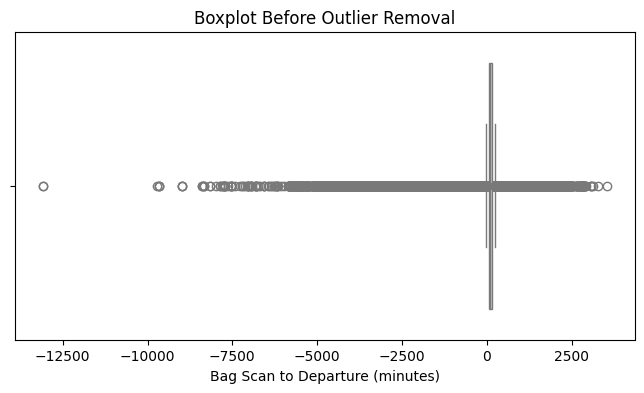

In [ ]:
#Outlier Handling on Target Variable (Before removing outliers)
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_sample['BAG_SCAN_TO_DEP_MIN'], color='lightblue')
plt.title("Boxplot Before Outlier Removal")
plt.xlabel("Bag Scan to Departure (minutes)")
plt.show()

In [ ]:
#Outlier removal
Q1 = df_sample['BAG_SCAN_TO_DEP_MIN'].quantile(0.25)
Q3 = df_sample['BAG_SCAN_TO_DEP_MIN'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_sample = df_sample[(df_sample['BAG_SCAN_TO_DEP_MIN'] >= lower_bound) & (df_sample['BAG_SCAN_TO_DEP_MIN'] <= upper_bound)]
print("After outlier removal:", df_sample.shape)


After outlier removal: (9474984, 29)


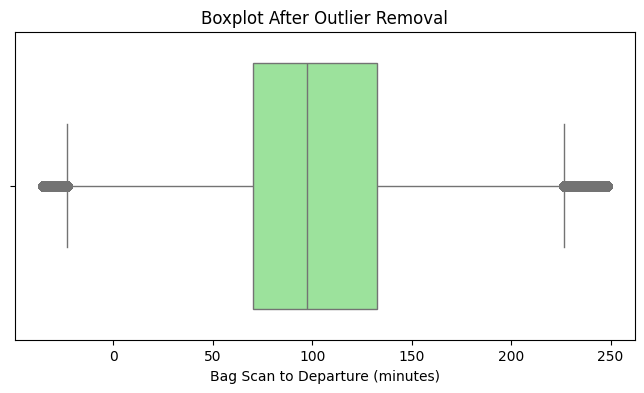

In [ ]:
# Box Plot after removing outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_sample['BAG_SCAN_TO_DEP_MIN'], color='lightgreen')
plt.title("Boxplot After Outlier Removal")
plt.xlabel("Bag Scan to Departure (minutes)")
plt.show()

In [ ]:
#Label Encoding for categorical columns
categorical_cols = [
    'OPERAT_AIRLN_IATA_CD', 'SCHD_LEG_DEP_AIRPRT_IATA_CD', 'SCHD_LEG_ARVL_AIRPRT_IATA_CD',
    'SUB_FLEET_CD', 'BODYTYPE', 'OPERATIONTYPE', 'AVL_STA_REGION_ICAO_CD',
    'AVL_STA_MIRS_PRIORITY_REGION_DESC'
]
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_sample[col] = le.fit_transform(df_sample[col].astype(str))
    label_encoders[col] = le

In [ ]:
#Feature Selection
features = [
    'OPERAT_AIRLN_IATA_CD', 'SCHD_LEG_DEP_AIRPRT_IATA_CD', 'SCHD_LEG_ARVL_AIRPRT_IATA_CD',
    'MILE_GREAT_CIRCLE_DISTANC_QTY', 'FLIGHT_LEG_TTL_AVAIL_SEAT_CT',
    # 'SCHD_AIRCAFT_EQUIP_CD',  # Remove this problematic feature for now
    'CREW_EQUIP_CD', 'FLEET_CD', 'SUB_FLEET_CD', 'BODYTYPE', 'OPERATIONTYPE',
    'AVL_STA_REGION_ICAO_CD', 'AVL_STA_MIRS_PRIORITY_CD', 'INTERNATIONAL', 'BANK_ID',
    'MKT_DAY_FREQUENCY', 'MKT_WEEK_FREQUENCY', 'MKT_DAY_DEP_SEQ',
    'DEP_HOUR', 'DEP_DAY_OF_WEEK', 'DEP_MONTH'
]
target = 'BAG_SCAN_TO_DEP_MIN'

X = df_sample[features]
y = df_sample[target]

In [ ]:
# Generate correlation matrix for features and target
correlation_matrix = df_sample[features + [target]].corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                               OPERAT_AIRLN_IATA_CD  \
OPERAT_AIRLN_IATA_CD                            NaN   
SCHD_LEG_DEP_AIRPRT_IATA_CD                     NaN   
SCHD_LEG_ARVL_AIRPRT_IATA_CD                    NaN   
MILE_GREAT_CIRCLE_DISTANC_QTY                   NaN   
FLIGHT_LEG_TTL_AVAIL_SEAT_CT                    NaN   
CREW_EQUIP_CD                                   NaN   
FLEET_CD                                        NaN   
SUB_FLEET_CD                                    NaN   
BODYTYPE                                        NaN   
OPERATIONTYPE                                   NaN   
AVL_STA_REGION_ICAO_CD                          NaN   
AVL_STA_MIRS_PRIORITY_CD                        NaN   
INTERNATIONAL                                   NaN   
BANK_ID                                         NaN   
MKT_DAY_FREQUENCY                               NaN   
MKT_WEEK_FREQUENCY                              NaN   
MKT_DAY_DEP_SEQ                              

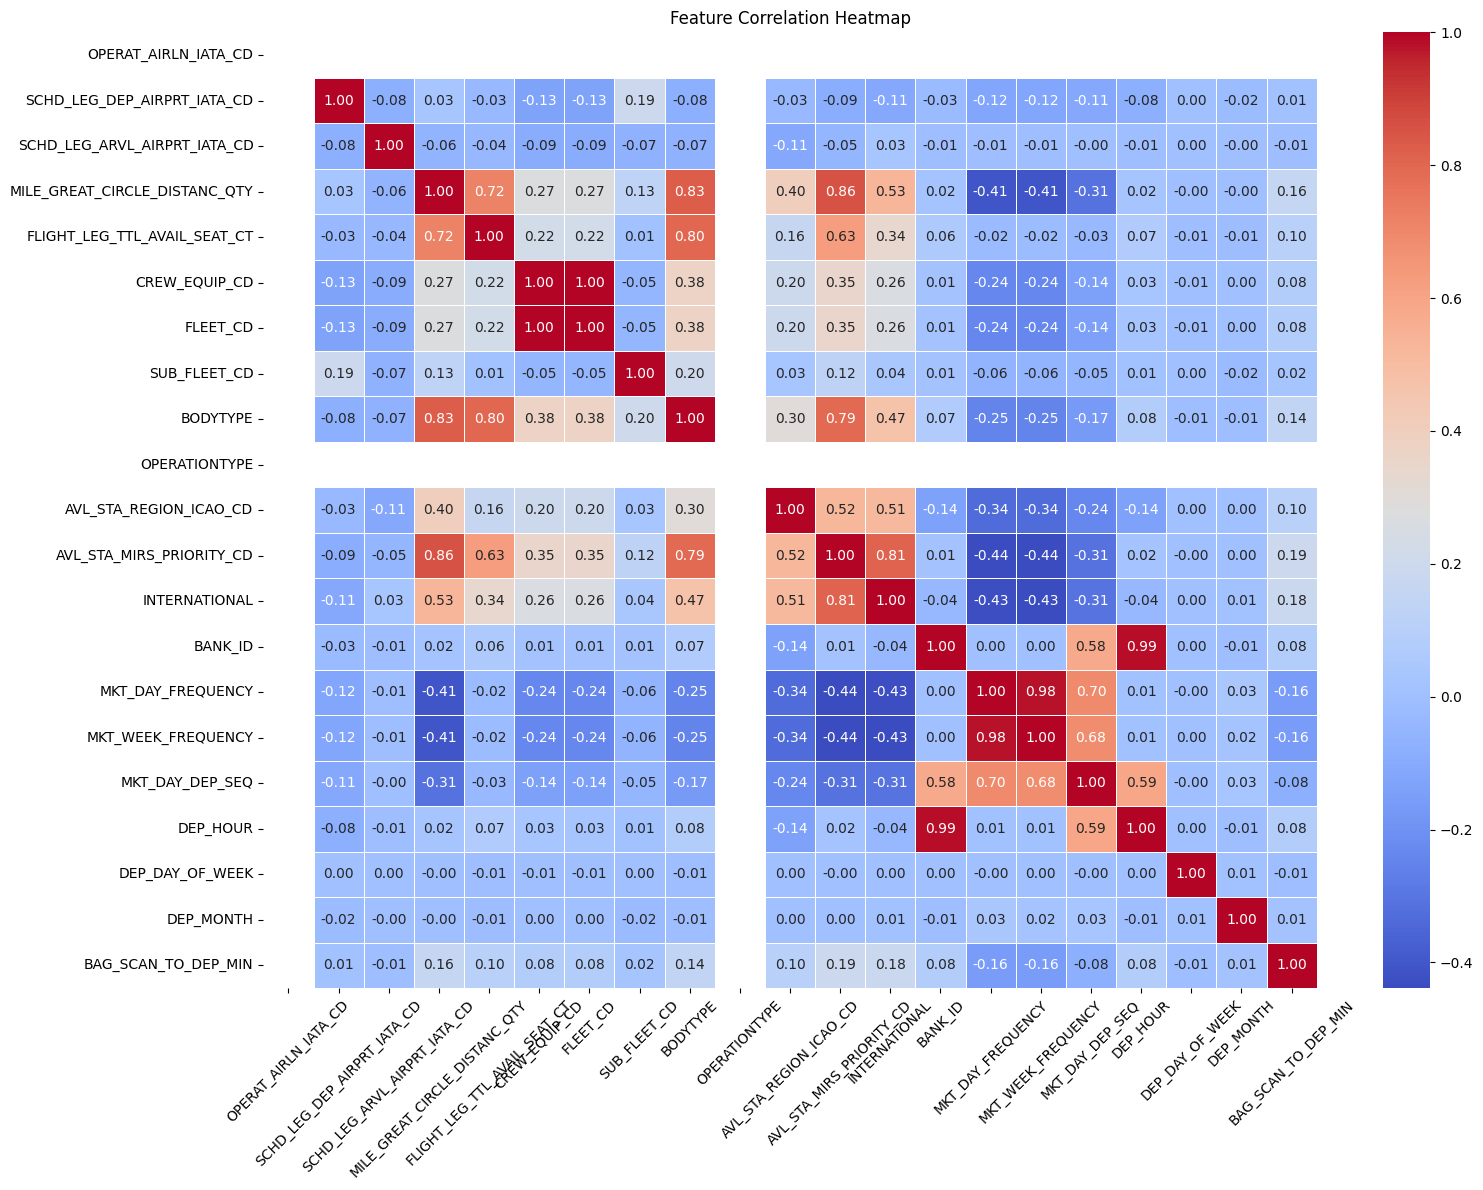

In [ ]:
#Correlation heatmap analysis
plt.figure(figsize=(16,12))
sns.heatmap(df_sample[features + [target]].corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


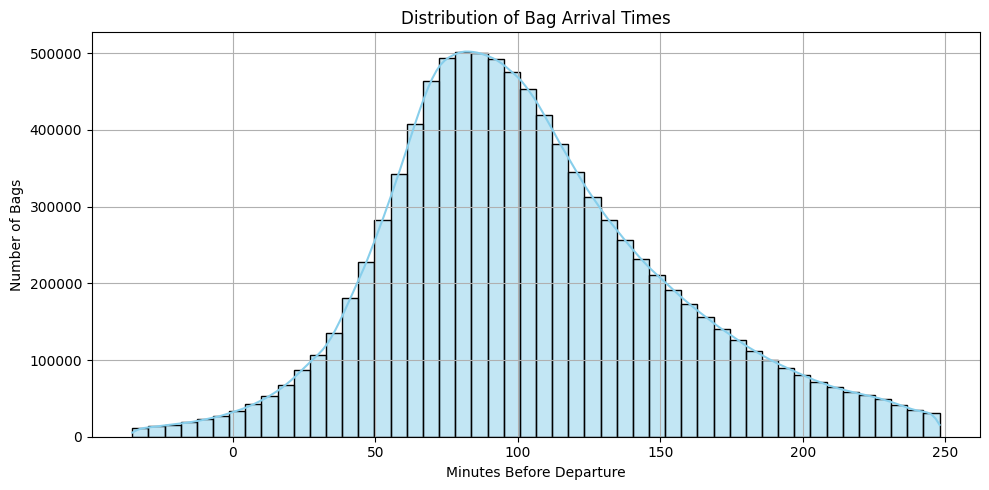

In [ ]:
#EDA
#Bag Arrival Time Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_sample['BAG_SCAN_TO_DEP_MIN'], bins=50, kde=True, color='skyblue')
plt.title("Distribution of Bag Arrival Times")
plt.xlabel("Minutes Before Departure")
plt.ylabel("Number of Bags")
plt.gca().xaxis
plt.grid(True)
plt.tight_layout()
plt.show()

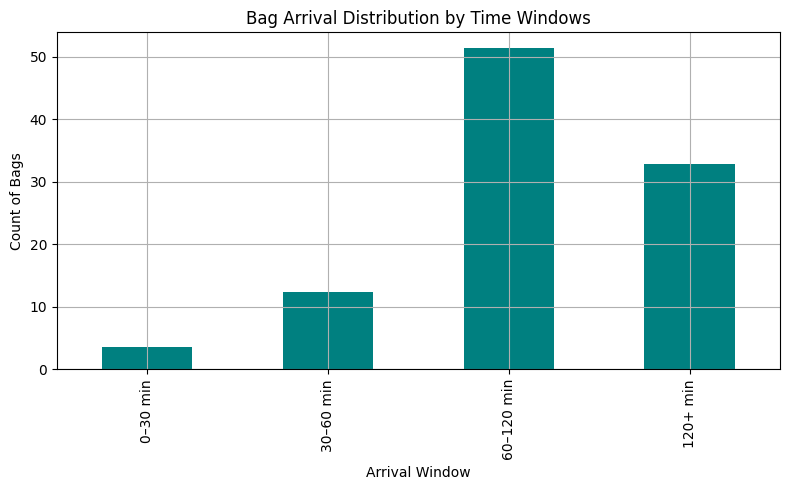

In [ ]:
#Bag Arrival Window Distribution
plt.figure(figsize=(8, 5))
(df_sample['Arrival_Window'].value_counts(normalize=True).sort_index() * 100).plot(kind='bar', color='teal')
plt.title("Bag Arrival Distribution by Time Windows")
plt.xlabel("Arrival Window")
plt.ylabel("Count of Bags")
plt.grid(True)
plt.tight_layout()
plt.show()

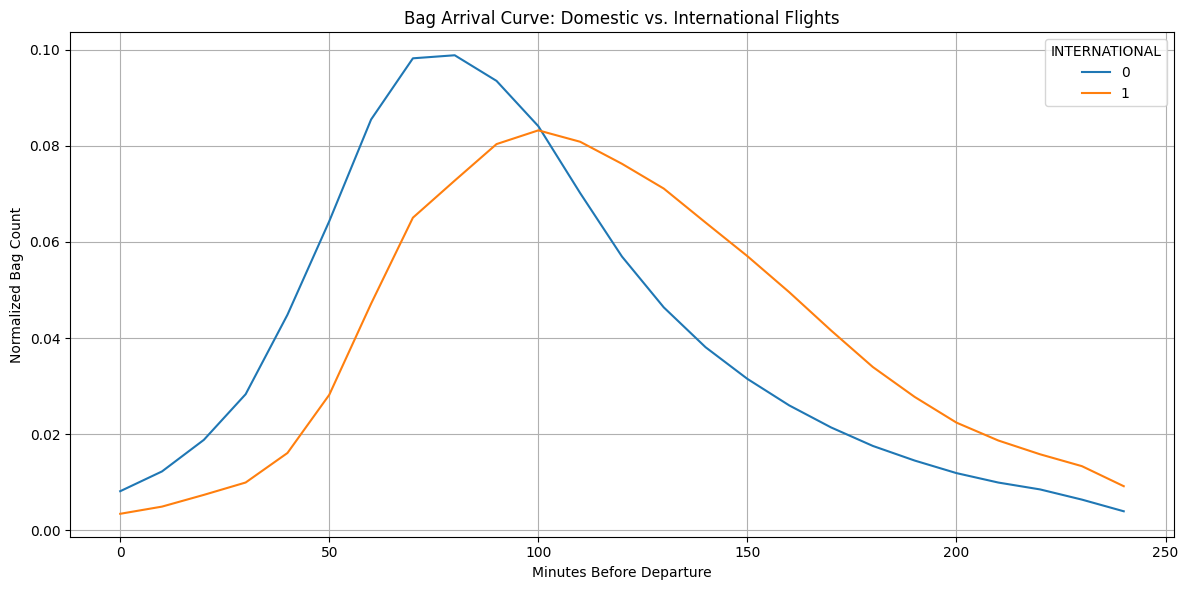

In [ ]:
# Domestic vs. International Bag Arrival Curves
df_sample = df_sample[df_sample['BAG_SCAN_TO_DEP_MIN'] >= 0]
df_sample['time_bin'] = (df_sample['BAG_SCAN_TO_DEP_MIN'] // 10) * 10
arrival_curve = df_sample.groupby(['INTERNATIONAL', 'time_bin']).size().reset_index(name='bag_count')
arrival_curve['normalized'] = arrival_curve.groupby('INTERNATIONAL')['bag_count'].transform(lambda x: x / x.sum())

plt.figure(figsize=(12, 6))
sns.lineplot(data=arrival_curve, x='time_bin', y='normalized', hue='INTERNATIONAL')
plt.gca().xaxis
plt.title("Bag Arrival Curve: Domestic vs. International Flights")
plt.xlabel("Minutes Before Departure")
plt.ylabel("Normalized Bag Count")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Linear Regression
print("\nTraining Linear Regression...")
gc.collect()

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Model Evaluation:")
print(f"MAE: {mae_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")
print(f"R2 Score: {r2_lr:.4f}")


Training Linear Regression...
Linear Regression Model Evaluation:
MAE: 37.56
RMSE: 48.14
R2 Score: 0.0535


In [ ]:
#Random Forest
print("\nTraining Random Forest...")
gc.collect()

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Model Evaluation:")
print(f"MAE: {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R2 Score: {r2_rf:.4f}")


Training Random Forest...
Random Forest Model Evaluation:
MAE: 36.13
RMSE: 46.33
R2 Score: 0.1235


In [ ]:
gc.collect()

0

In [ ]:
#MLP Regressor
print("\nTraining MLP Regressor...")
gc.collect()

mlp_model = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=200, random_state=42)
mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)

mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2_mlp = r2_score(y_test, y_pred_mlp)

print("MLP Regressor Model Evaluation:")
print(f"MAE: {mae_mlp:.2f}")
print(f"RMSE: {rmse_mlp:.2f}")
print(f"R2 Score: {r2_mlp:.4f}")


Training MLP Regressor...
MLP Regressor Model Evaluation:
MAE: 37.16
RMSE: 47.67
R2 Score: 0.0719


In [ ]:
#LightGBM
print("\nTraining LightGBM...")
gc.collect()

lgbm_model = LGBMRegressor(random_state=42)
lgbm_model.fit(X_train, y_train)
y_pred_lgbm = lgbm_model.predict(X_test)

mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
r2_lgbm = r2_score(y_test, y_pred_lgbm)

print("LightGBM Model Evaluation:")
print(f"MAE: {mae_lgbm:.2f}")
print(f"RMSE: {rmse_lgbm:.2f}")
print(f"R2 Score: {r2_lgbm:.4f}")


Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.182367 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 689
[LightGBM] [Info] Number of data points in the train set: 7579987, number of used features: 18
[LightGBM] [Info] Start training from score 103.706372
LightGBM Model Evaluation:
MAE: 37.02
RMSE: 47.45
R2 Score: 0.0804


In [ ]:
#Combining and Display the Evaluation Metrics for All Models
evaluation_df = pd.DataFrame({
    'MAE': [mae_lr, mae_rf, mae_mlp, mae_lgbm],
    'RMSE': [rmse_lr, rmse_rf, rmse_mlp, rmse_lgbm],
    'R2 Score': [r2_lr, r2_rf, r2_mlp, r2_lgbm]
}, index=['Linear Regression', 'Random Forest', 'MLP Regressor', 'LightGBM'])

print("\nModel Evaluation Summary:")
display(evaluation_df)


Model Evaluation Summary:


,MAE,RMSE,R2 Score
Linear Regression,37.560925,48.141125,0.053546
Random Forest,36.132573,46.327498,0.123514
MLP Regressor,37.417639,47.888069,0.063470
LightGBM,37.021537,47.453432,0.080393


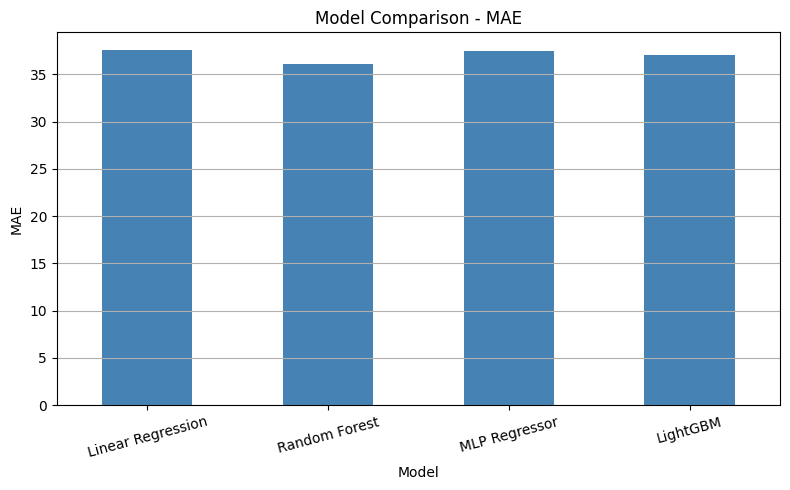

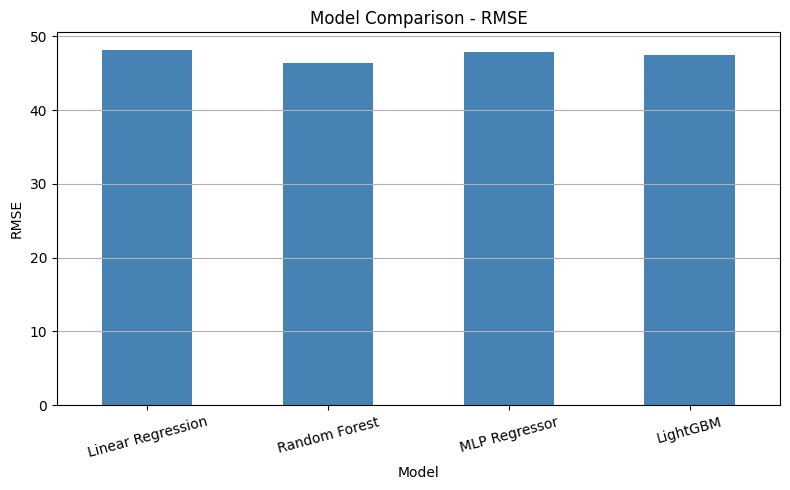

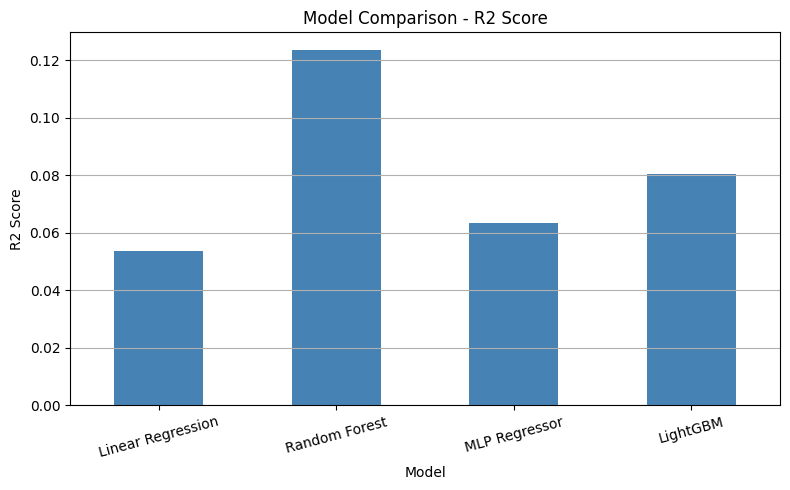

In [ ]:
#Creating a DataFrame from your computed metrics
final_df = pd.DataFrame({
    'MAE': [mae_lr, mae_rf, mae_mlp, mae_lgbm],
    'RMSE': [rmse_lr, rmse_rf, rmse_mlp, rmse_lgbm],
    'R2 Score': [r2_lr, r2_rf, r2_mlp, r2_lgbm]
}, index=['Linear Regression', 'Random Forest', 'MLP Regressor', 'LightGBM'])

#Plot each metric separately
for metric in final_df.columns:
    plt.figure(figsize=(8, 5))
    final_df[metric].plot(kind='bar', color='steelblue')
    plt.title(f'Model Comparison - {metric}')
    plt.ylabel(metric)
    plt.xlabel('Model')
    plt.xticks(rotation=15)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()


In [ ]:
#Perfroming RandomizedSearchCV on Random Forest (Hyperparameter Tuning)
print("\nHyperparameter Tuning for Random Forest using RandomizedSearchCV...")
gc.collect()


#Defining the hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}

#Initialize RandomizedSearchCV
rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=20,                 # number of combinations to try (smaller = faster)
    cv=3,                      # 3-fold cross-validation
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

#Fitting RandomizedSearchCV
rf_random.fit(X_train, y_train)

#Best model from search
best_rf_random = rf_random.best_estimator_
print("\nBest Hyperparameters (Randomized Search):", rf_random.best_params_)

#Prediction using best model
y_pred_rf_random = best_rf_random.predict(X_test)

#Evaluation
mae_rf_random = mean_absolute_error(y_test, y_pred_rf_random)
rmse_rf_random = np.sqrt(mean_squared_error(y_test, y_pred_rf_random))
r2_rf_random = r2_score(y_test, y_pred_rf_random)

print("\nTuned Random Forest (RandomizedSearchCV) Evaluation:")
print(f"MAE: {mae_rf_random:.2f}")
print(f"RMSE: {rmse_rf_random:.2f}")
print(f"R2 Score: {r2_rf_random:.4f}")


Hyperparameter Tuning for Random Forest using RandomizedSearchCV...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Hyperparameters (Randomized Search): {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 30}

Tuned Random Forest (RandomizedSearchCV) Evaluation:
MAE: 36.11
RMSE: 46.29
R2 Score: 0.1250


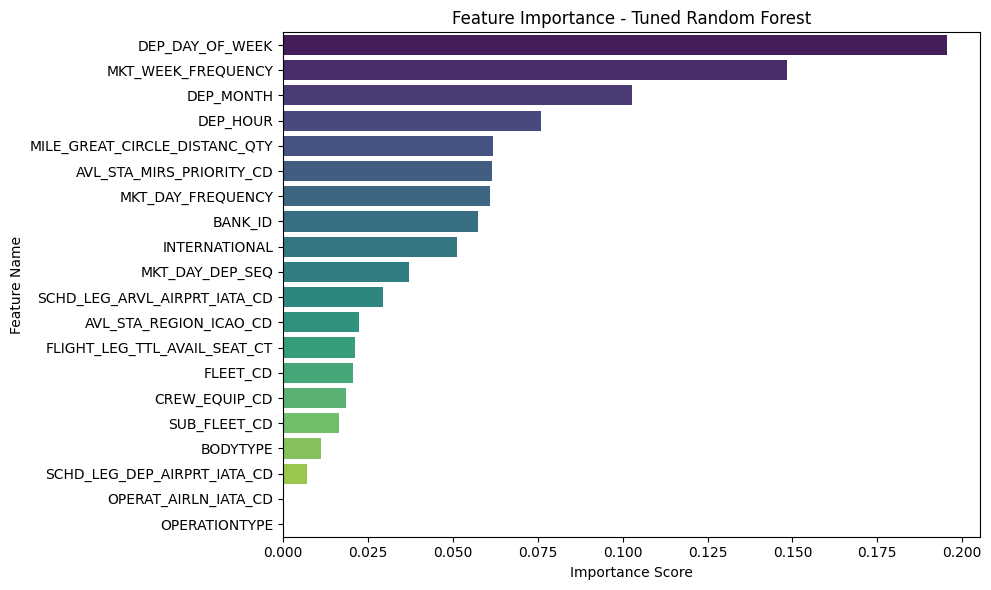

In [ ]:
#Feature Importance for Tuned Random Forest
importances = best_rf_random.feature_importances_
feature_names = X_train.columns

#Create a DataFrame for easy viewing
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

#Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title("Feature Importance - Tuned Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()



Predicted Average Bag Arrival Time by Flight Type:
INTERNATIONAL
0     99.668313
1    123.434955
Name: Predicted_Bag_Scan_Min, dtype: float64


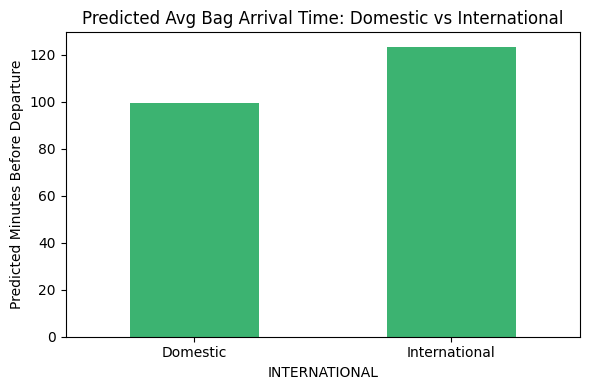

In [ ]:
#Comparing domestic(0) vs international(1) flights using bar graph (Random Forest)
X_test_with_flag = X_test.copy()
X_test_with_flag['INTERNATIONAL'] = df_sample.loc[X_test.index, 'INTERNATIONAL']
X_test_with_flag['Predicted_Bag_Scan_Min'] = y_pred_rf

avg_predicted_by_type = X_test_with_flag.groupby('INTERNATIONAL')['Predicted_Bag_Scan_Min'].mean()
print("\nPredicted Average Bag Arrival Time by Flight Type:")
print(avg_predicted_by_type)

plt.figure(figsize=(6, 4))
avg_predicted_by_type.sort_index().plot(kind='bar', color='mediumseagreen')
plt.xticks([0, 1], ['Domestic', 'International'], rotation=0)
plt.title("Predicted Avg Bag Arrival Time: Domestic vs International")
plt.ylabel("Predicted Minutes Before Departure")
plt.tight_layout()
plt.show()

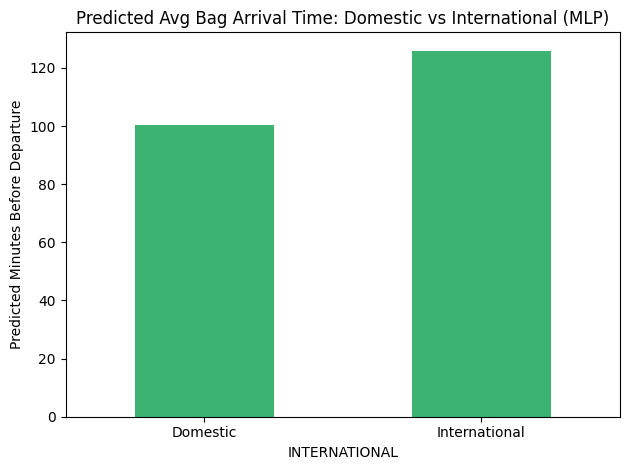

In [ ]:
#Comparing domestic(0) vs international(1) flights using bar graph (MLP Regressor)
X_test_mlp = X_test.copy()
X_test_mlp['INTERNATIONAL'] = df_sample.loc[X_test.index, 'INTERNATIONAL']
X_test_mlp['Predicted_BAG_SCAN_TO_DEP_MIN'] = y_pred_mlp

avg_pred_by_type = (
    X_test_mlp.groupby('INTERNATIONAL')['Predicted_BAG_SCAN_TO_DEP_MIN']
    .mean()
    .rename({0: 'Domestic', 1: 'International'})
)

avg_pred_by_type.plot(kind='bar', color='mediumseagreen')
plt.title("Predicted Avg Bag Arrival Time: Domestic vs International (MLP)")
plt.ylabel("Predicted Minutes Before Departure")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


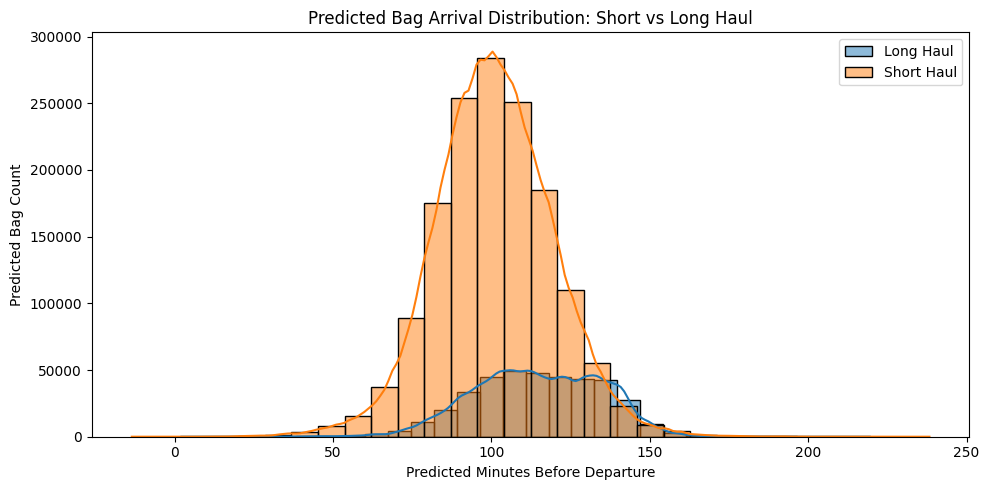

In [ ]:
#Bag arrival distribution for Short vs Long Haul flight (Random Forest)
X_test_with_flag = X_test.copy()
X_test_with_flag['SHORT_HAUL'] = df_sample.loc[X_test.index, 'SHORT_HAUL']
X_test_with_flag['Predicted_Bag_Scan_Min'] = y_pred_rf

plt.figure(figsize=(10, 5))
for label, group in X_test_with_flag.groupby('SHORT_HAUL'):
    sns.histplot(
        group['Predicted_Bag_Scan_Min'],
        label='Short Haul' if label else 'Long Haul',
        bins=30,
        kde=True
    )

plt.title("Predicted Bag Arrival Distribution: Short vs Long Haul")
plt.xlabel("Predicted Minutes Before Departure")
plt.ylabel("Predicted Bag Count")
plt.legend()
plt.tight_layout()
plt.show()

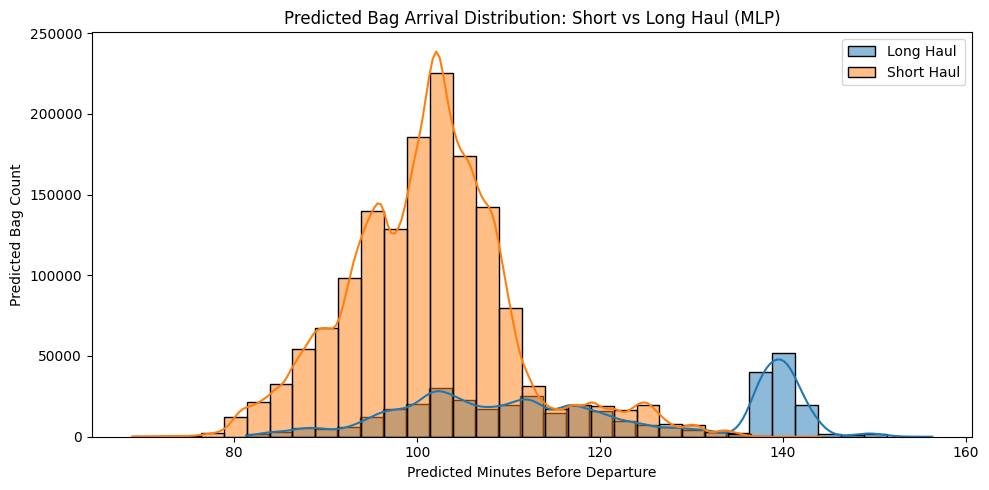

In [ ]:
#Bag arrival distribution for Short vs Long Haul flight (MLP Regressor)
X_test_mlp = X_test.copy()
X_test_mlp['SHORT_HAUL'] = df_sample.loc[X_test.index, 'SHORT_HAUL']
X_test_mlp['Predicted_Bag_Scan_Min'] = y_pred_mlp

plt.figure(figsize=(10, 5))
for label, group in X_test_mlp.groupby('SHORT_HAUL'):
    sns.histplot(
        group['Predicted_Bag_Scan_Min'],
        label='Short Haul' if label else 'Long Haul',
        bins=30,
        kde=True
    )

plt.title("Predicted Bag Arrival Distribution: Short vs Long Haul (MLP)")
plt.xlabel("Predicted Minutes Before Departure")
plt.ylabel("Predicted Bag Count")
plt.legend()
plt.tight_layout()
plt.show()

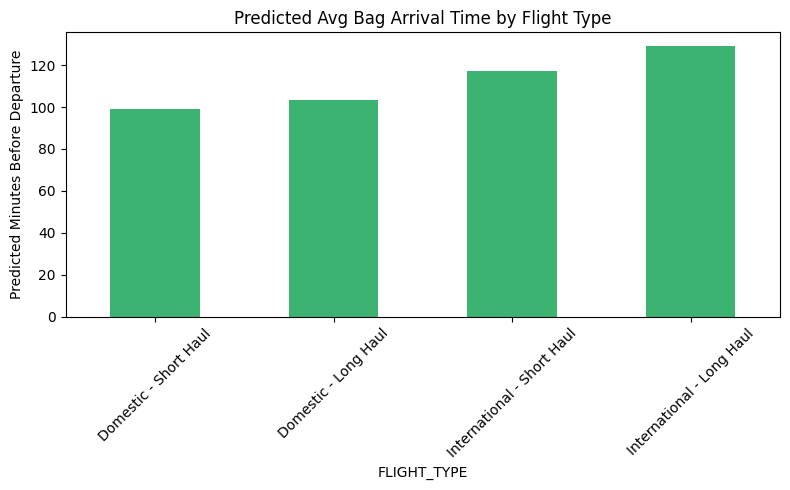

In [ ]:
#Creating a combined bar chart for domestic(short vs long haul flight) and international(short vs long haul flight) (Random Forest)
X_test_with_flags = X_test.copy()
X_test_with_flags['INTERNATIONAL'] = df_sample.loc[X_test.index, 'INTERNATIONAL']
X_test_with_flags['MILE_GREAT_CIRCLE_DISTANC_QTY'] = df_sample.loc[X_test.index, 'MILE_GREAT_CIRCLE_DISTANC_QTY']
X_test_with_flags['Predicted_Bag_Scan_Min'] = y_pred_rf

X_test_with_flags['FLIGHT_TYPE'] = X_test_with_flags.apply(
    lambda row: f"{'International' if row['INTERNATIONAL'] else 'Domestic'} - {'Short' if row['MILE_GREAT_CIRCLE_DISTANC_QTY'] < 1500 else 'Long'} Haul",
    axis=1
)

avg_pred_by_flight_type = (
    X_test_with_flags
    .groupby('FLIGHT_TYPE')['Predicted_Bag_Scan_Min']
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))
avg_pred_by_flight_type.plot(kind='bar', color='mediumseagreen')
plt.title("Predicted Avg Bag Arrival Time by Flight Type")
plt.ylabel("Predicted Minutes Before Departure")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

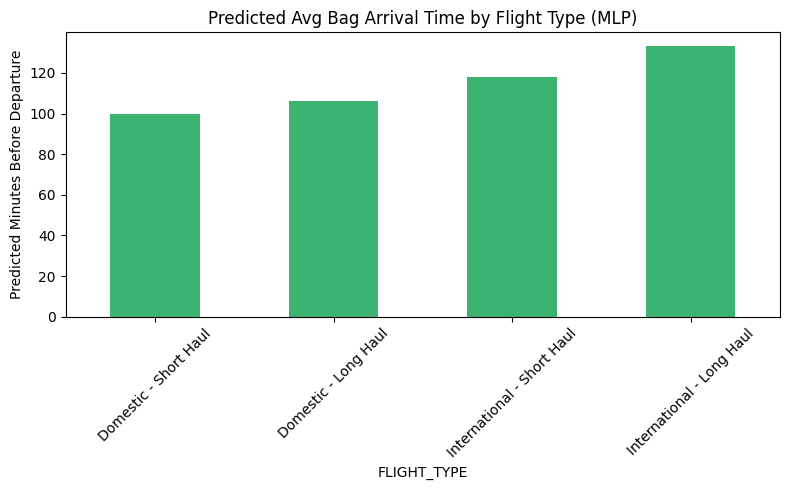

In [ ]:
#Creating a combined bar chart for domestic(short vs long haul flight) and international(short vs long haul flight) (MLP Regressor)
X_test_mlp = X_test.copy()
X_test_mlp['INTERNATIONAL'] = df_sample.loc[X_test.index, 'INTERNATIONAL']
X_test_mlp['MILE_GREAT_CIRCLE_DISTANC_QTY'] = df_sample.loc[X_test.index, 'MILE_GREAT_CIRCLE_DISTANC_QTY']
X_test_mlp['Predicted_Bag_Scan_Min'] = y_pred_mlp

X_test_mlp['FLIGHT_TYPE'] = X_test_mlp.apply(
    lambda row: f"{'International' if row['INTERNATIONAL'] else 'Domestic'} - {'Short' if row['MILE_GREAT_CIRCLE_DISTANC_QTY'] < 1500 else 'Long'} Haul",
    axis=1
)

avg_pred_by_flight_type = (
    X_test_mlp
    .groupby('FLIGHT_TYPE')['Predicted_Bag_Scan_Min']
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))
avg_pred_by_flight_type.plot(kind='bar', color='mediumseagreen')
plt.title("Predicted Avg Bag Arrival Time by Flight Type (MLP)")
plt.ylabel("Predicted Minutes Before Departure")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


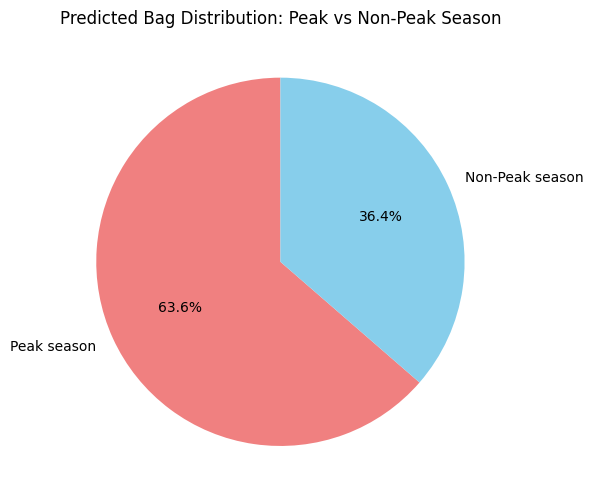

In [ ]:
#Percentage of bags arrived during peak and non-peak season (Random Forest)
X_test_with_flag = X_test.copy()
X_test_with_flag['PEAK_SEASON'] = df_sample.loc[X_test.index, 'PEAK_SEASON'] # Use df_sample instead of df
X_test_with_flag['Predicted_Bag_Scan_Min'] = y_pred_rf

peak_pred_counts = (
    X_test_with_flag
    .groupby('PEAK_SEASON')['Predicted_Bag_Scan_Min']
    .count()
    .sort_index()
)

peak_pred_percent = peak_pred_counts / peak_pred_counts.sum() * 100

peak_labels = [ 'Peak season', 'Non-Peak season']

plt.figure(figsize=(6, 6))
plt.pie(
    peak_pred_percent,
    labels=peak_labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=['lightcoral', 'skyblue']
)
plt.title("Predicted Bag Distribution: Peak vs Non-Peak Season")
plt.tight_layout()
plt.show()

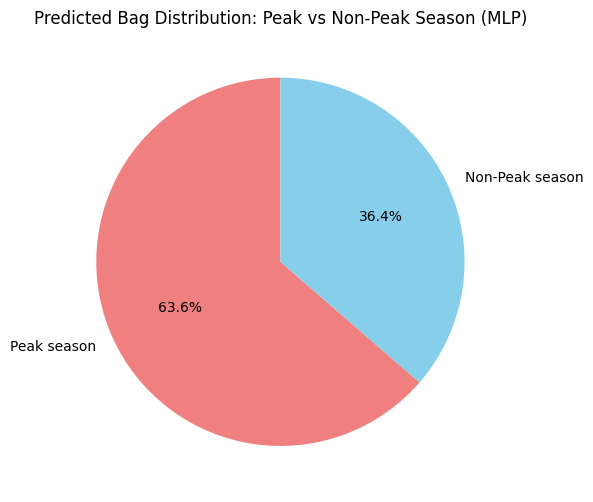

In [ ]:
#Percentage of bags arrived during peak and non-peak season (MLP Regressor)
X_test_mlp = X_test.copy()
X_test_mlp['PEAK_SEASON'] = df_sample.loc[X_test.index, 'PEAK_SEASON']  # Use df_sample
X_test_mlp['Predicted_Bag_Scan_Min'] = y_pred_mlp

#Counting predictions by PEAK_SEASON
peak_pred_counts_mlp = (
    X_test_mlp
    .groupby('PEAK_SEASON')['Predicted_Bag_Scan_Min']
    .count()
    .sort_index()
)

#Converting counts to percentage
peak_pred_percent_mlp = peak_pred_counts_mlp / peak_pred_counts_mlp.sum() * 100

#Defining labels
peak_labels = ['Peak season', 'Non-Peak season']

#Plotting pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    peak_pred_percent_mlp,
    labels=peak_labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=['lightcoral', 'skyblue']
)
plt.title("Predicted Bag Distribution: Peak vs Non-Peak Season (MLP)")
plt.tight_layout()
plt.show()

In [ ]:
#Garbage collector
gc.collect()

20037

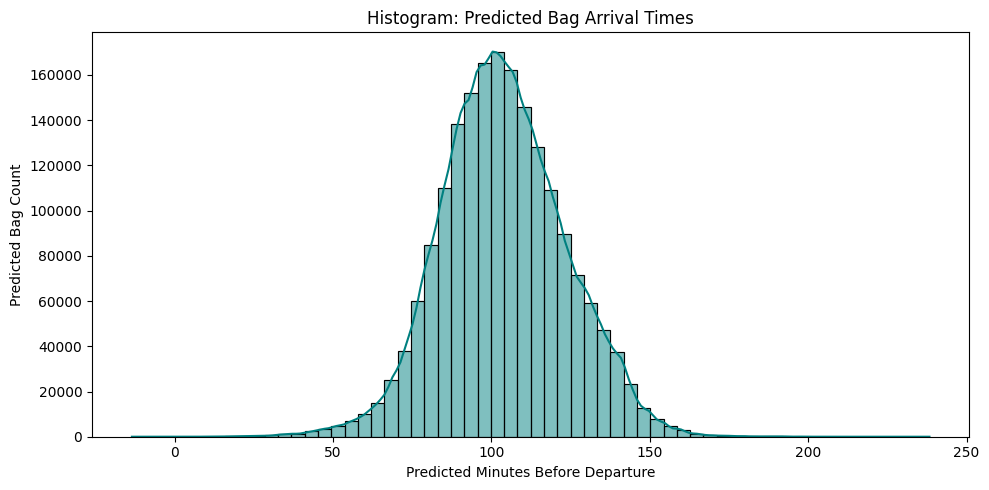

In [ ]:
#Percent of Bags in Time Windows (Random Forest)
plt.figure(figsize=(10, 5))
sns.histplot(y_pred_rf, bins=60, color='teal', kde=True)

plt.title("Histogram: Predicted Bag Arrival Times")
plt.xlabel("Predicted Minutes Before Departure")
plt.ylabel("Predicted Bag Count")
plt.tight_layout()
plt.show()


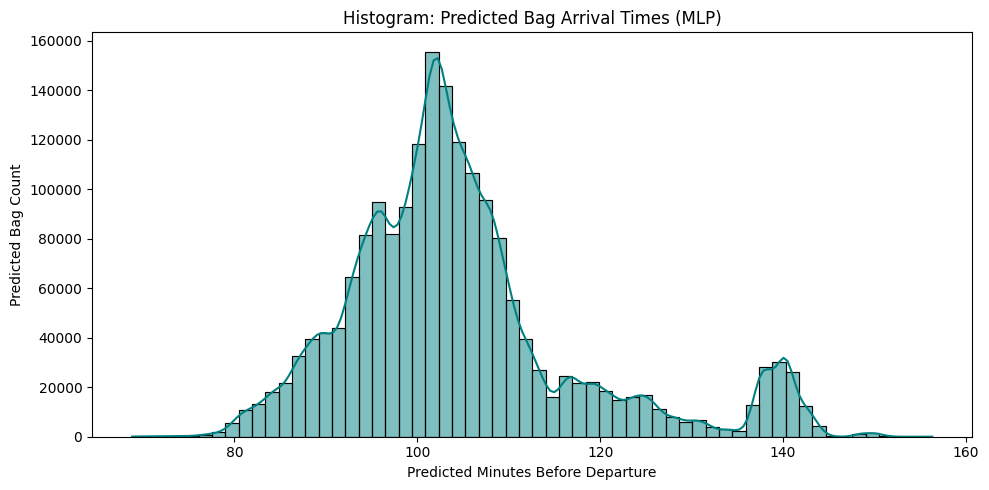

In [ ]:
#Percent of Bags in Time Windows (MLP Regressor)
plt.figure(figsize=(10, 5))
sns.histplot(y_pred_mlp, bins=60, color='teal', kde=True)

plt.title("Histogram: Predicted Bag Arrival Times (MLP)")
plt.xlabel("Predicted Minutes Before Departure")
plt.ylabel("Predicted Bag Count")
plt.tight_layout()
plt.show()


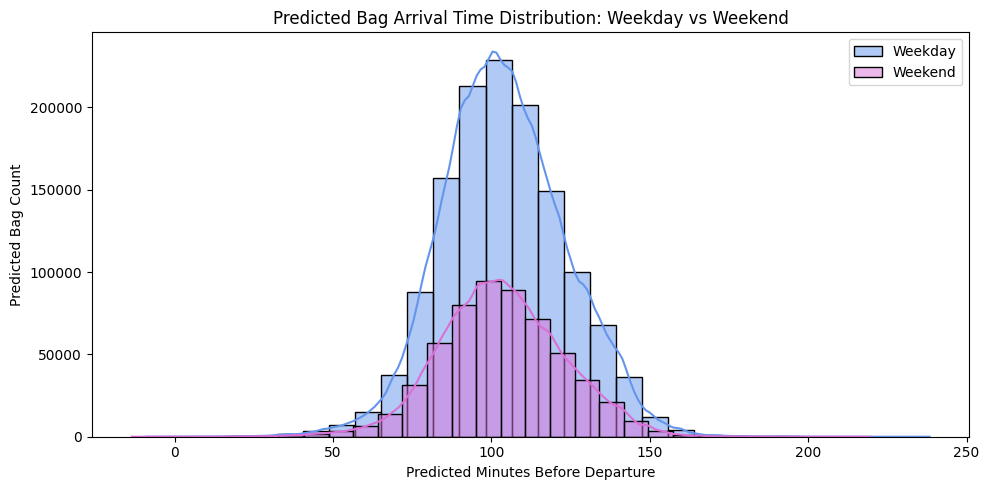

In [ ]:
#Day of Week (Weekday vs Weekend) (Random Forest)
X_test_with_flag = X_test.copy()
# Use df_sample to access DEP_DAY_OF_WEEK as it's created during feature engineering
X_test_with_flag['DEP_DAY_OF_WEEK'] = df_sample.loc[X_test.index, 'DEP_DAY_OF_WEEK']
X_test_with_flag['WEEKEND'] = X_test_with_flag['DEP_DAY_OF_WEEK'].apply(lambda x: True if x >= 5 else False)
X_test_with_flag['Predicted_Bag_Scan_Min'] = y_pred_rf

plt.figure(figsize=(10, 5))
sns.histplot(
    X_test_with_flag[X_test_with_flag['WEEKEND'] == False]['Predicted_Bag_Scan_Min'],
    label='Weekday',
    bins=30,
    kde=True,
    color='cornflowerblue'
)
sns.histplot(
    X_test_with_flag[X_test_with_flag['WEEKEND'] == True]['Predicted_Bag_Scan_Min'],
    label='Weekend',
    bins=30,
    kde=True,
    color='orchid'
)

plt.title("Predicted Bag Arrival Time Distribution: Weekday vs Weekend")
plt.xlabel("Predicted Minutes Before Departure")
plt.ylabel("Predicted Bag Count")
plt.legend()
plt.tight_layout()
plt.show()

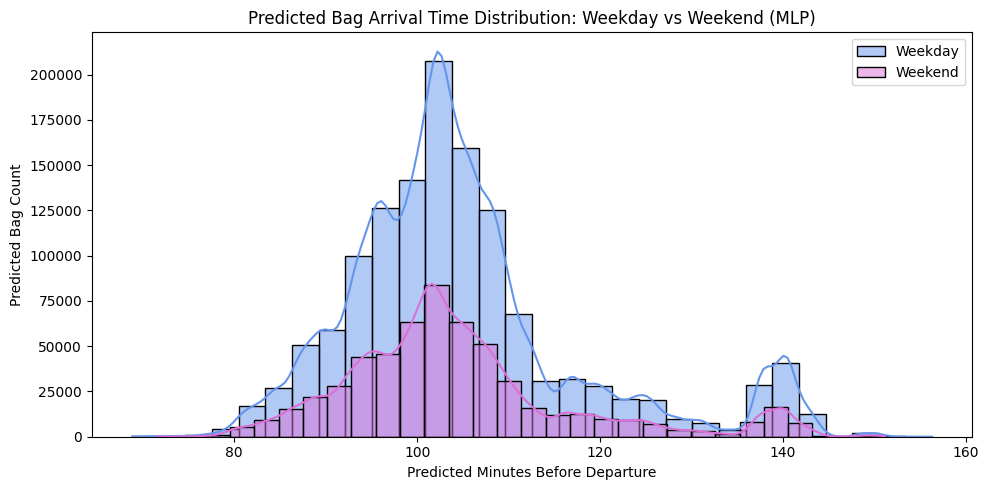

In [ ]:
#Day of Week (Weekday vs Weekend) (MLP Regressor)

X_test_mlp = X_test.copy()
# Use df_sample to access DEP_DAY_OF_WEEK, as it was created during feature engineering
X_test_mlp['DEP_DAY_OF_WEEK'] = df_sample.loc[X_test.index, 'DEP_DAY_OF_WEEK']
X_test_mlp['WEEKEND'] = X_test_mlp['DEP_DAY_OF_WEEK'].apply(lambda x: True if x >= 5 else False)
X_test_mlp['Predicted_Bag_Scan_Min'] = y_pred_mlp

plt.figure(figsize=(10, 5))
sns.histplot(
    X_test_mlp[X_test_mlp['WEEKEND'] == False]['Predicted_Bag_Scan_Min'],
    label='Weekday',
    bins=30,
    kde=True,
    color='cornflowerblue'
)
sns.histplot(
    X_test_mlp[X_test_mlp['WEEKEND'] == True]['Predicted_Bag_Scan_Min'],
    label='Weekend',
    bins=30,
    kde=True,
    color='orchid'
)

plt.title("Predicted Bag Arrival Time Distribution: Weekday vs Weekend (MLP)")
plt.xlabel("Predicted Minutes Before Departure")
plt.ylabel("Predicted Bag Count")
plt.legend()
plt.tight_layout()
plt.show()

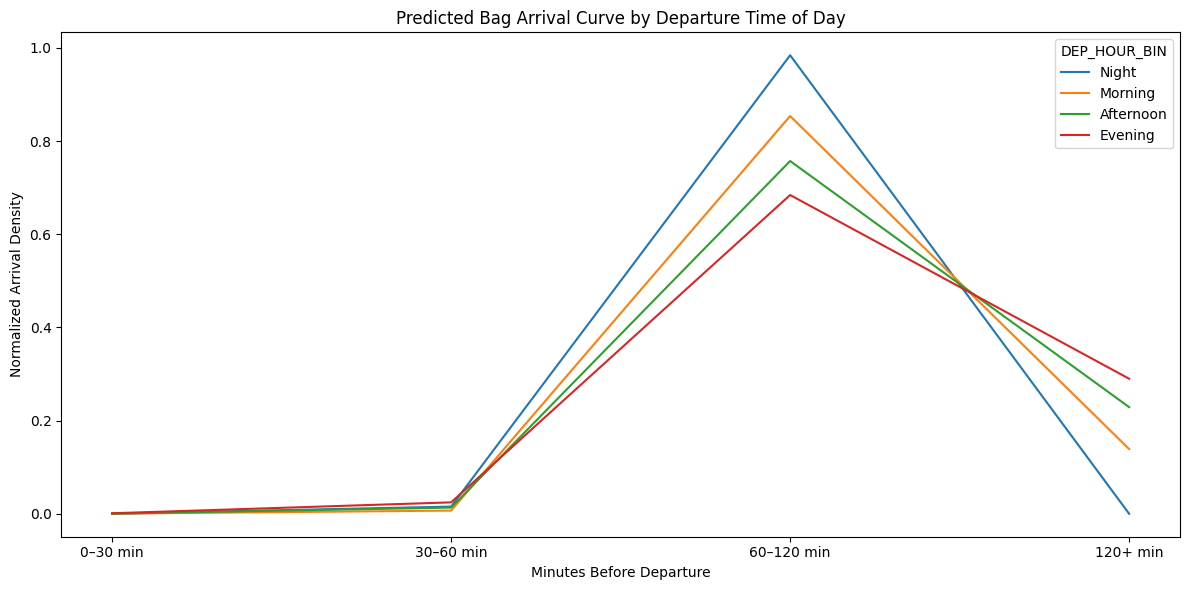

In [ ]:
#Displaying bag arrival departure time in a day (Random Forest)
X_test_pred = X_test.copy()
X_test_pred['DEP_HOUR'] = df_sample.loc[X_test.index, 'DEP_HOUR']
X_test_pred['Predicted_Bag_Scan_Min'] = y_pred_rf

X_test_pred['DEP_HOUR_BIN'] = pd.cut(
    X_test_pred['DEP_HOUR'],
    bins=[0, 6, 12, 18, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening']
)

time_bins = [0, 30, 60, 120, float('inf')]
time_labels = ['0–30 min', '30–60 min', '60–120 min', '120+ min']
X_test_pred['time_bin'] = pd.cut(X_test_pred['Predicted_Bag_Scan_Min'], bins=time_bins, labels=time_labels)

arrival_curve_pred = (
    X_test_pred.groupby(['DEP_HOUR_BIN', 'time_bin'])
    .size()
    .reset_index(name='bag_count')
)
arrival_curve_pred['normalized'] = arrival_curve_pred.groupby('DEP_HOUR_BIN')['bag_count'].transform(lambda x: x / x.sum())

plt.figure(figsize=(12, 6))
sns.lineplot(data=arrival_curve_pred, x='time_bin', y='normalized', hue='DEP_HOUR_BIN')
plt.title("Predicted Bag Arrival Curve by Departure Time of Day")
plt.xlabel("Minutes Before Departure")
plt.ylabel("Normalized Arrival Density")
plt.tight_layout()
plt.show()

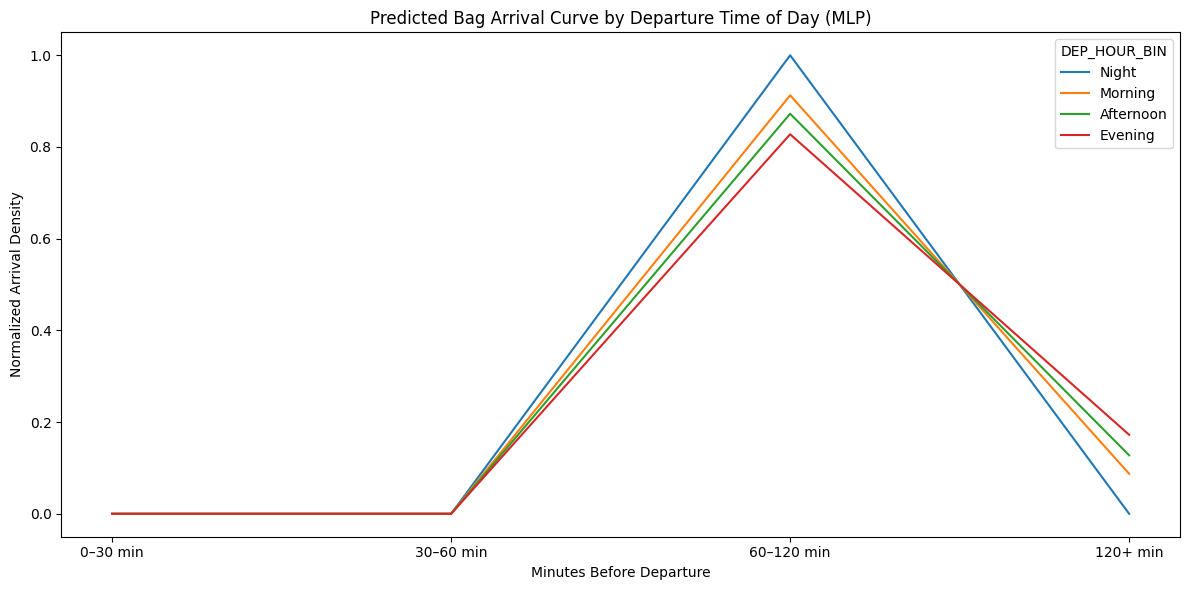

In [ ]:
#Displaying bag arrival departure time in a day (MLP Regressor)
X_test_mlp = X_test.copy()
X_test_mlp['DEP_HOUR'] = df_sample.loc[X_test.index, 'DEP_HOUR']
X_test_mlp['Predicted_Bag_Scan_Min'] = y_pred_mlp

X_test_mlp['DEP_HOUR_BIN'] = pd.cut(
    X_test_mlp['DEP_HOUR'],
    bins=[0, 6, 12, 18, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening']
)

time_bins = [0, 30, 60, 120, float('inf')]
time_labels = ['0–30 min', '30–60 min', '60–120 min', '120+ min']
X_test_mlp['time_bin'] = pd.cut(X_test_mlp['Predicted_Bag_Scan_Min'], bins=time_bins, labels=time_labels)

arrival_curve_pred = (
    X_test_mlp.groupby(['DEP_HOUR_BIN', 'time_bin'])
    .size()
    .reset_index(name='bag_count')
)
arrival_curve_pred['normalized'] = arrival_curve_pred.groupby('DEP_HOUR_BIN')['bag_count'].transform(lambda x: x / x.sum())

plt.figure(figsize=(12, 6))
sns.lineplot(data=arrival_curve_pred, x='time_bin', y='normalized', hue='DEP_HOUR_BIN')
plt.title("Predicted Bag Arrival Curve by Departure Time of Day (MLP)")
plt.xlabel("Minutes Before Departure")
plt.ylabel("Normalized Arrival Density")
plt.tight_layout()
plt.show()

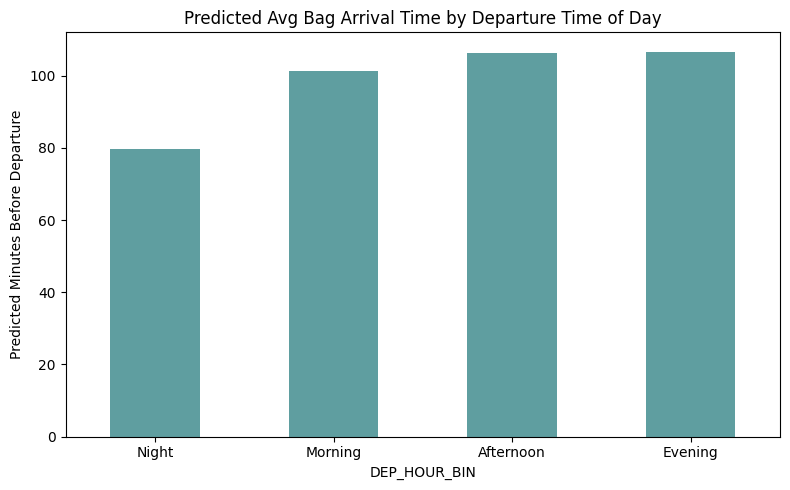

In [ ]:
#Average Arrival Time by Time of Day (Random Forest)
X_test_pred = X_test.copy()
X_test_pred['DEP_HOUR'] = df_sample.loc[X_test.index, 'DEP_HOUR'] # Changed df to df_sample
X_test_pred['Predicted_Bag_Scan_Min'] = y_pred_rf

X_test_pred['DEP_HOUR_BIN'] = pd.cut(
    X_test_pred['DEP_HOUR'],
    bins=[0, 6, 12, 18, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening']
)

avg_pred_by_hour = (
    X_test_pred.groupby('DEP_HOUR_BIN')['Predicted_Bag_Scan_Min']
    .mean()
    .sort_index()
)

plt.figure(figsize=(8, 5))
avg_pred_by_hour.plot(kind='bar', color='cadetblue')
plt.title("Predicted Avg Bag Arrival Time by Departure Time of Day")
plt.ylabel("Predicted Minutes Before Departure")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

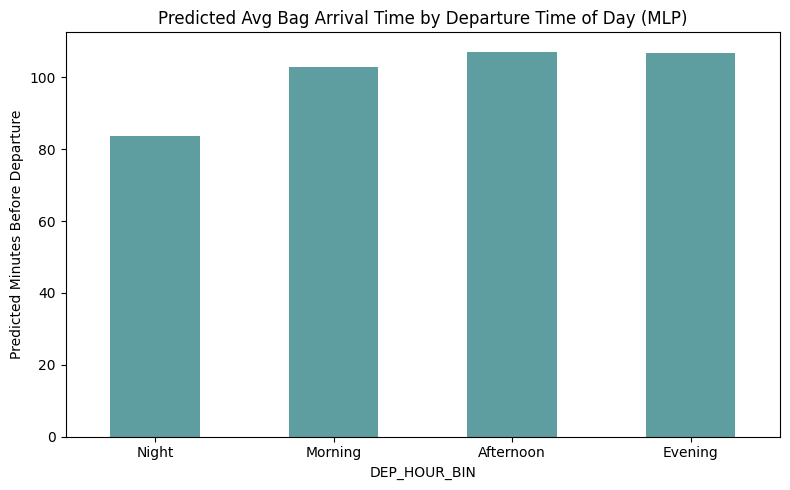

In [ ]:
#Average Arrival Time by Time of Day (MLP Regressor)
X_test_mlp = X_test.copy()
X_test_mlp['DEP_HOUR'] = df_sample.loc[X_test.index, 'DEP_HOUR']  # Changed df to df_sample
X_test_mlp['Predicted_Bag_Scan_Min'] = y_pred_mlp

X_test_mlp['DEP_HOUR_BIN'] = pd.cut(
    X_test_mlp['DEP_HOUR'],
    bins=[0, 6, 12, 18, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening']
)

avg_pred_by_hour = (
    X_test_mlp.groupby('DEP_HOUR_BIN')['Predicted_Bag_Scan_Min']
    .mean()
    .sort_index()
)

plt.figure(figsize=(8, 5))
avg_pred_by_hour.plot(kind='bar', color='cadetblue')
plt.title("Predicted Avg Bag Arrival Time by Departure Time of Day (MLP)")
plt.ylabel("Predicted Minutes Before Departure")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

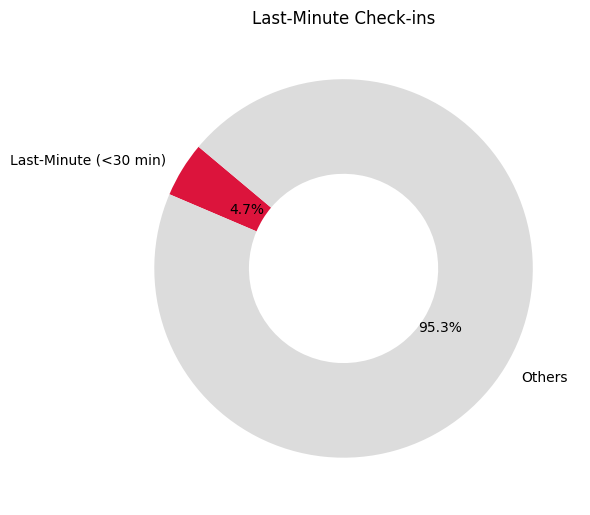

In [ ]:
#Calculating the percentange of last minute checked-in bag
share_last_minute = (df_sample['BAG_SCAN_TO_DEP_MIN'] <= 30).sum() / len(df_sample) * 100
last_minute_share = [share_last_minute, 100 - share_last_minute]
labels = ['Last-Minute (<30 min)', 'Others']
colors = ['crimson', 'gainsboro']

plt.figure(figsize=(6, 6))
plt.pie(last_minute_share, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, wedgeprops=dict(width=0.5))
plt.title("Last-Minute Check-ins")
plt.tight_layout()
plt.show()

In [ ]:
#Printing models performnce for each metric
print("ML Model Performance Summary:")

data = {
    'Model': ['Random Forest', 'Linear Regression', 'MLP Regressor', 'LightGBM'],
    'MAE': [mae_rf, mae_lr, mae_mlp, mae_lgbm],
    'RMSE': [rmse_rf, rmse_lr, rmse_mlp, rmse_lgbm],
    'R2 Score': [r2_rf, r2_lr, r2_mlp, r2_lgbm]
}
final_df = pd.DataFrame(data)

display(final_df)

ML Model Performance Summary:


,Model,MAE,RMSE,R2 Score
0,Random Forest,36.132573,46.327498,0.123514
1,Linear Regression,37.560925,48.141125,0.053546
2,MLP Regressor,37.417639,47.888069,0.063470
3,LightGBM,37.021537,47.453432,0.080393


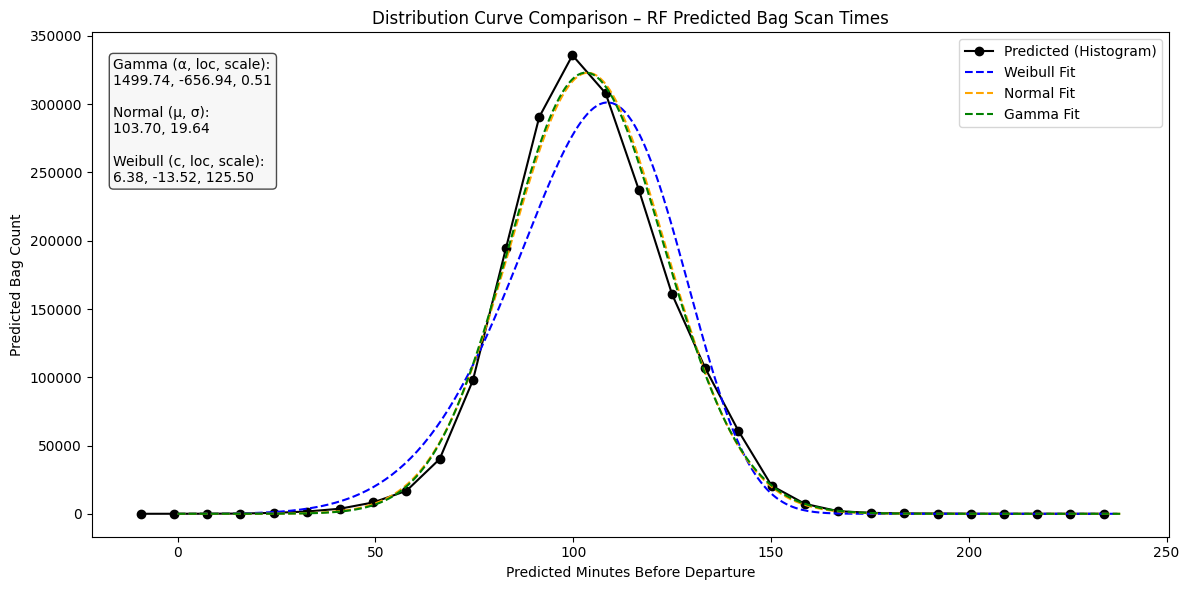

In [ ]:
#Predictions of Bag Arrival Curve from Random Forest
predicted_scan_times = y_pred_rf

#Fitting distributions using stats
gamma_params = stats.gamma.fit(predicted_scan_times)
normal_params = stats.norm.fit(predicted_scan_times)
weibull_params = stats.weibull_min.fit(predicted_scan_times)

#Fitting distributions
gamma_params = stats.gamma.fit(predicted_scan_times)
normal_params = stats.norm.fit(predicted_scan_times)
weibull_params = stats.weibull_min.fit(predicted_scan_times)

#Generating x-axis points
x = np.linspace(0, predicted_scan_times.max(), 300)

#Creating histogram
counts, bin_edges = np.histogram(predicted_scan_times, bins=30)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

#Calculating fitted PDFs scaled to histogram
gamma_pdf = stats.gamma.pdf(x, *gamma_params) * len(predicted_scan_times) * bin_width
normal_pdf = stats.norm.pdf(x, *normal_params) * len(predicted_scan_times) * bin_width
weibull_pdf = stats.weibull_min.pdf(x, *weibull_params) * len(predicted_scan_times) * bin_width

#Plotting
plt.figure(figsize=(12, 6))
plt.plot(bin_centers, counts, 'ko-', label='Predicted (Histogram)')
plt.plot(x, weibull_pdf, 'b--', label='Weibull Fit')
plt.plot(x, normal_pdf, color='orange', linestyle='--', label='Normal Fit')
plt.plot(x, gamma_pdf, 'g--', label='Gamma Fit')

plt.title("Distribution Curve Comparison – RF Predicted Bag Scan Times")
plt.xlabel("Predicted Minutes Before Departure")
plt.ylabel("Predicted Bag Count")
plt.legend()

#Adding text box with fitted parameters
params_text = (
    f"Gamma (α, loc, scale):\n"
    f"{gamma_params[0]:.2f}, {gamma_params[1]:.2f}, {gamma_params[2]:.2f}\n\n"
    f"Normal (μ, σ):\n"
    f"{normal_params[0]:.2f}, {normal_params[1]:.2f}\n\n"
    f"Weibull (c, loc, scale):\n"
    f"{weibull_params[0]:.2f}, {weibull_params[1]:.2f}, {weibull_params[2]:.2f}"
)
plt.gca().text(
    0.02, 0.95, params_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='whitesmoke', alpha=0.7)
)

plt.tight_layout()
plt.show()

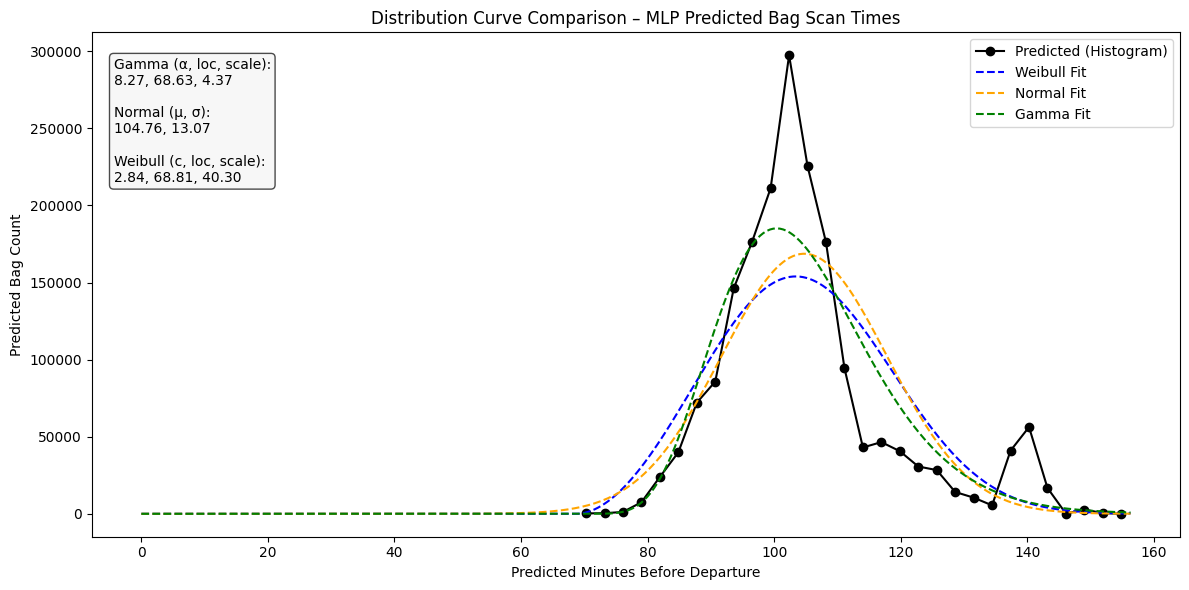

In [ ]:
#Predictions of Bag Arrival curve from MLP
predicted_scan_times = y_pred_mlp

#Fitting distributions
gamma_params = stats.gamma.fit(predicted_scan_times)
normal_params = stats.norm.fit(predicted_scan_times)
weibull_params = stats.weibull_min.fit(predicted_scan_times)

#Creating x points
x = np.linspace(0, predicted_scan_times.max(), 300)

#Creating Histogram
counts, bin_edges = np.histogram(predicted_scan_times, bins=30)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

#Calculating fitted PDFs scaled to histogram
gamma_pdf = stats.gamma.pdf(x, *gamma_params) * len(predicted_scan_times) * bin_width
normal_pdf = stats.norm.pdf(x, *normal_params) * len(predicted_scan_times) * bin_width
weibull_pdf = stats.weibull_min.pdf(x, *weibull_params) * len(predicted_scan_times) * bin_width

#Plotting
plt.figure(figsize=(12, 6))
plt.plot(bin_centers, counts, 'ko-', label='Predicted (Histogram)')
plt.plot(x, weibull_pdf, 'b--', label='Weibull Fit')
plt.plot(x, normal_pdf, color='orange', linestyle='--', label='Normal Fit')
plt.plot(x, gamma_pdf, 'g--', label='Gamma Fit')

plt.title("Distribution Curve Comparison – MLP Predicted Bag Scan Times")
plt.xlabel("Predicted Minutes Before Departure")
plt.ylabel("Predicted Bag Count")
plt.legend()

#Adding text box with fitted parameters
params_text = (
    f"Gamma (α, loc, scale):\n"
    f"{gamma_params[0]:.2f}, {gamma_params[1]:.2f}, {gamma_params[2]:.2f}\n\n"
    f"Normal (μ, σ):\n"
    f"{normal_params[0]:.2f}, {normal_params[1]:.2f}\n\n"
    f"Weibull (c, loc, scale):\n"
    f"{weibull_params[0]:.2f}, {weibull_params[1]:.2f}, {weibull_params[2]:.2f}"
)
plt.gca().text(
    0.02, 0.95, params_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='whitesmoke', alpha=0.7)
)

plt.tight_layout()
plt.show()

In [ ]:
#Decoding label encoding for airport codes
SCHD_LEG_DEP_label_encoder = label_encoders['SCHD_LEG_DEP_AIRPRT_IATA_CD']
dfw_code = SCHD_LEG_DEP_label_encoder.transform(['DFW'])[0]
phx_code = SCHD_LEG_DEP_label_encoder.transform(['PHX'])[0]

In [ ]:
#Filtering 2% of the data
df_full = pq_file.read().to_pandas()  # Use pq_file instead of table

#Label encode airports if not done yet
df_full['SCHD_LEG_DEP_AIRPRT_IATA_CD'] = label_encoders['SCHD_LEG_DEP_AIRPRT_IATA_CD'].transform(df_full['SCHD_LEG_DEP_AIRPRT_IATA_CD'].astype(str))

#Get numeric code for DFW and PHX
dfw_code = label_encoders['SCHD_LEG_DEP_AIRPRT_IATA_CD'].transform(['DFW'])[0]
phx_code = label_encoders['SCHD_LEG_DEP_AIRPRT_IATA_CD'].transform(['PHX'])[0]

#Filter and sample
df_dfw = df_full[df_full['SCHD_LEG_DEP_AIRPRT_IATA_CD'] == dfw_code].sample(frac=0.2, random_state=42)
df_phx = df_full[df_full['SCHD_LEG_DEP_AIRPRT_IATA_CD'] == phx_code].sample(frac=0.2, random_state=42)

#check shapes
print("DFW Sample Shape:", df_dfw.shape)
print("PHX Sample Shape:", df_phx.shape)

DFW Sample Shape: (8751896, 33)
PHX Sample Shape: (1441785, 33)


In [ ]:
#Fit-and-predict function

def fit_and_predict_model(df_filtered, model):
    X = df_filtered[features]
    y = df_filtered[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return y_test, y_pred

In [ ]:
# Step 5: Add time-based features and target
def add_features(df):
    df['SCHD_LEG_DEP_LCL_TMS'] = pd.to_datetime(df['SCHD_LEG_DEP_LCL_TMS'])
    df['BAG_SCAN_LCL_TMS'] = pd.to_datetime(df['BAG_SCAN_LCL_TMS'])
    df['BAG_SCAN_TO_DEP_MIN'] = (df['SCHD_LEG_DEP_LCL_TMS'] - df['BAG_SCAN_LCL_TMS']).dt.total_seconds() / 60 # Calculate target variable
    df['DEP_HOUR'] = df['SCHD_LEG_DEP_LCL_TMS'].dt.hour
    df['DEP_DAY_OF_WEEK'] = df['SCHD_LEG_DEP_LCL_TMS'].dt.dayofweek
    df['DEP_MONTH'] = df['SCHD_LEG_DEP_LCL_TMS'].dt.month
    df['PEAK_SEASON'] = df['DEP_MONTH'].isin([6, 7, 11, 12])
    df['SHORT_HAUL'] = df['MILE_GREAT_CIRCLE_DISTANC_QTY'] < 1500
    return df

df_dfw = add_features(df_dfw)
df_phx = add_features(df_phx)


# Step 6: Define features and target
features = [
    'MILE_GREAT_CIRCLE_DISTANC_QTY', 'FLIGHT_LEG_TTL_AVAIL_SEAT_CT',
    'DEP_HOUR', 'DEP_DAY_OF_WEEK', 'DEP_MONTH'
]
target = 'BAG_SCAN_TO_DEP_MIN'

# Step 7: Fit + Predict function
def fit_and_predict_model(df_filtered, model):
    X = df_filtered[features]
    y = df_filtered[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return y_test, y_pred

# Step 8: Train on each subset
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
y_test_dfw, y_pred_dfw = fit_and_predict_model(df_dfw, rf_model)
y_test_phx, y_pred_phx = fit_and_predict_model(df_phx, rf_model)

# Step 9: Plotting Function
def plot_fitted_curves_with_params(y_pred, title):
    gamma_params = gamma.fit(y_pred)
    normal_params = norm.fit(y_pred)
    weibull_params = weibull_min.fit(y_pred)

    x = np.linspace(0, max(y_pred), 300)
    counts, bin_edges = np.histogram(y_pred, bins=30)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]

    gamma_pdf = gamma.pdf(x, *gamma_params) * len(y_pred) * bin_width
    normal_pdf = norm.pdf(x, *normal_params) * len(y_pred) * bin_width
    weibull_pdf = weibull_min.pdf(x, *weibull_params) * len(y_pred) * bin_width

    plt.figure(figsize=(12, 6))
    plt.plot(bin_centers, counts, 'ko-', label='Predicted Histogram')
    plt.plot(x, gamma_pdf, 'g--', label=f'Gamma Fit (α={gamma_params[0]:.2f}, loc={gamma_params[1]:.2f}, scale={gamma_params[2]:.2f})')
    plt.plot(x, normal_pdf, 'orange', linestyle='--', label=f'Normal Fit (μ={normal_params[0]:.2f}, σ={normal_params[1]:.2f})')
    plt.plot(x, weibull_pdf, 'b--', label=f'Weibull Fit (c={weibull_params[0]:.2f}, loc={weibull_params[1]:.2f}, scale={weibull_params[2]:.2f})')

    plt.title(f"Distribution Curve Comparison – {title}")
    plt.xlabel("Predicted Minutes Before Departure")
    plt.ylabel("Predicted Bag Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"\n{title} Curve Fit Parameters:")
    print(f"  Gamma:   α={gamma_params[0]:.4f}, loc={gamma_params[1]:.4f}, scale={gamma_params[2]:.4f}")
    print(f"  Normal:  μ={normal_params[0]:.4f}, σ={normal_params[1]:.4f}")
    print(f"  Weibull: c={weibull_params[0]:.4f}, loc={weibull_params[1]:.4f}, scale={weibull_params[2]:.4f}")


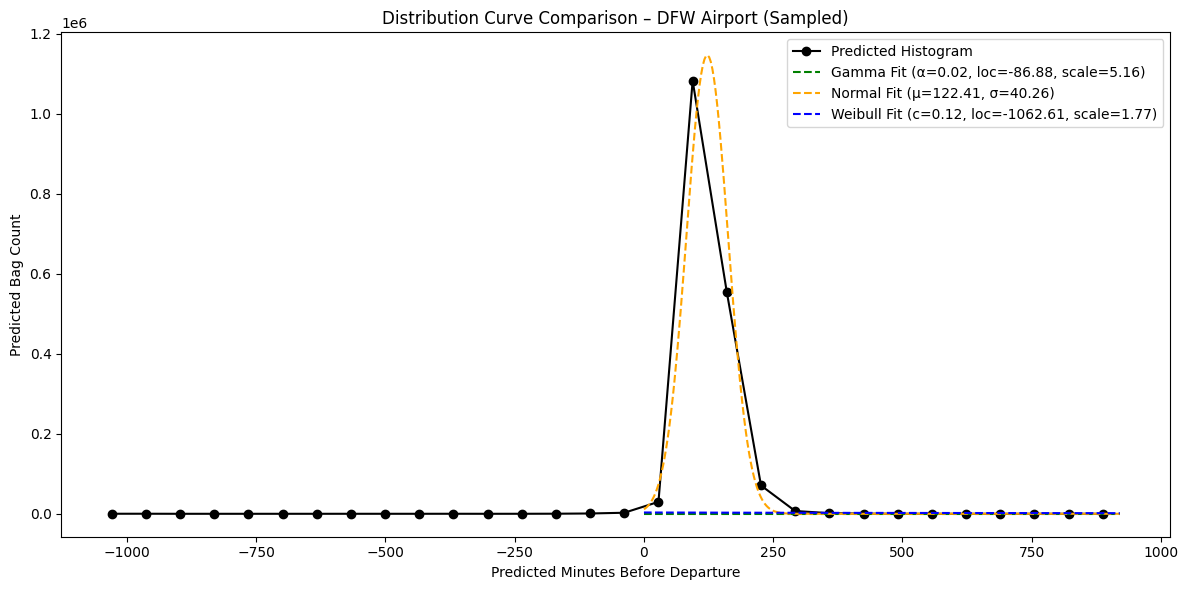


DFW Airport (Sampled) Curve Fit Parameters:
  Gamma:   α=0.0231, loc=-86.8829, scale=5.1639
  Normal:  μ=122.4101, σ=40.2634
  Weibull: c=0.1236, loc=-1062.6074, scale=1.7721


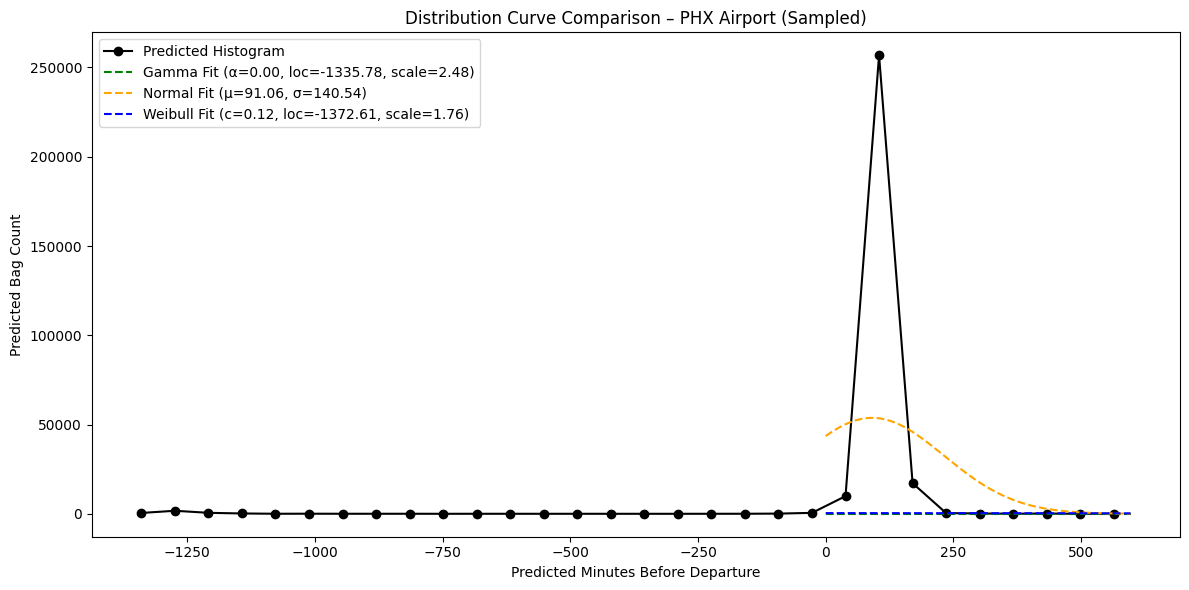


PHX Airport (Sampled) Curve Fit Parameters:
  Gamma:   α=0.0001, loc=-1335.7849, scale=2.4758
  Normal:  μ=91.0650, σ=140.5379
  Weibull: c=0.1198, loc=-1372.6052, scale=1.7626


In [ ]:
#Plotting for DFW and PHX from 2% sampled data
plot_fitted_curves_with_params(y_pred_dfw, "DFW Airport (Sampled)")
plot_fitted_curves_with_params(y_pred_phx, "PHX Airport (Sampled)")